# Exploratory Data Analysis (EDA) of the Netflix Titles Dataset

---

## Aim

The aim of this project is to perform Exploratory Data Analysis (EDA) on the Netflix Titles dataset using Python. The project involves understanding the dataset, cleaning missing values, performing statistical analysis, and creating visualizations to identify trends and patterns in Netflix's content library.

# 1. Importing Required Libraries

Pandas is used for data manipulation and analysis, while Matplotlib is used for creating various visualizations.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 2. Loading the Dataset

The Netflix dataset is loaded into a Pandas DataFrame.

In [2]:
data = pd.read_csv("netflix_titles_duration_minutes.csv")

# 3. Displaying the Dataset

The first few records are displayed to understand the structure of the dataset.

In [3]:
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90.0,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,960.0,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,480.0,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,480.0,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,960.0,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# 4. Displaying the Last Five Records

In [4]:
data.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158.0,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,960.0,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88.0,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88.0,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111.0,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


# 5. Shape of the Dataset

The shape tells us the number of rows and columns present in the dataset.

In [5]:
data.shape

(8807, 12)

# 6. Information About the Dataset

The info() function displays the column names, data types, and missing values.

In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       8807 non-null   str    
 1   type          8807 non-null   str    
 2   title         8807 non-null   str    
 3   director      6173 non-null   str    
 4   cast          7982 non-null   str    
 5   country       7976 non-null   str    
 6   date_added    8797 non-null   str    
 7   release_year  8807 non-null   int64  
 8   rating        8803 non-null   str    
 9   duration      8804 non-null   float64
 10  listed_in     8807 non-null   str    
 11  description   8807 non-null   str    
dtypes: float64(1), int64(1), str(10)
memory usage: 825.8 KB


# 7. Statistical Summary

The describe() function provides statistical information about numerical columns.

In [7]:
data.describe()

,release_year,duration
count,8807.000000,8804.000000
mean,2014.180198,326.811563
std,8.819312,542.405274
min,1925.000000,3.000000
25%,2013.000000,92.000000
50%,2017.000000,112.000000
75%,2019.000000,480.000000
max,2021.000000,8160.000000


# 8. Checking Missing Values

This step identifies missing values present in each column.

In [8]:
data.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

# 9. Data Cleaning

Missing values in the **director**, **cast**, and **country** columns are replaced with **"Unknown"**. Missing values in the **duration** column are replaced with the median duration.

In [9]:
data[['director','cast','country']] = data[['director','cast','country']].fillna("Unknown")

data['duration'] = data['duration'].fillna(data['duration'].median())

# 10. Verify Missing Values

Check whether the missing values have been handled successfully.

In [10]:
data.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           4
duration         0
listed_in        0
description      0
dtype: int64

# 11. Converting Date Column

The **date_added** column is converted into datetime format to simplify date-based analysis.

In [11]:
data['date_added'] = pd.to_datetime(data['date_added'].str.strip(), errors='coerce')

data['year_added'] = data['date_added'].dt.year

# 12. Line Graph – Netflix Titles Added Per Year

This graph shows how many titles were added to Netflix every year.

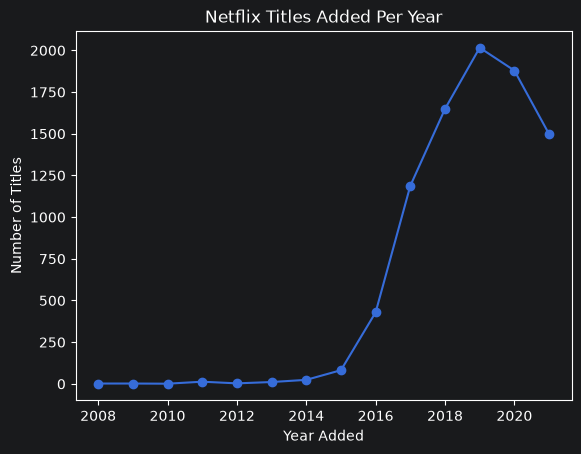

In [12]:
titles_per_year = data['year_added'].value_counts().sort_index()

titles_per_year.plot(kind='line', marker='o')

plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.title("Netflix Titles Added Per Year")

plt.show()

### Observation

The graph shows a significant increase in Netflix content additions after 2015, indicating rapid expansion of the platform.

# 13. Bar Graph – Movies vs TV Shows

This graph compares the number of movies and TV shows available on Netflix.

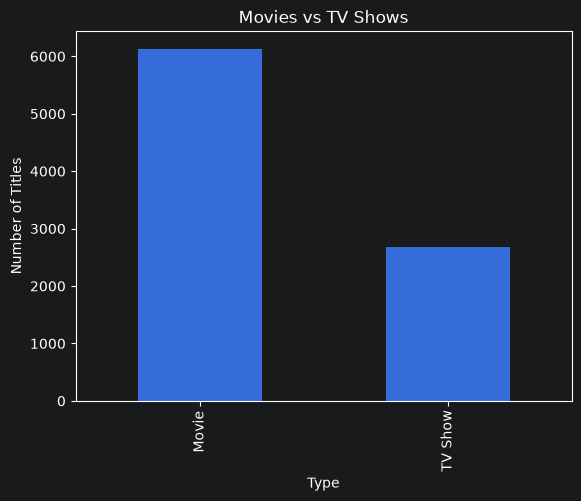

In [13]:
data['type'].value_counts().plot(kind='bar')

plt.xlabel("Type")
plt.ylabel("Number of Titles")
plt.title("Movies vs TV Shows")

plt.show()

### Observation

The dataset contains considerably more movies than TV shows.

# 14. Histogram – Duration Distribution

The histogram illustrates how movie durations are distributed.

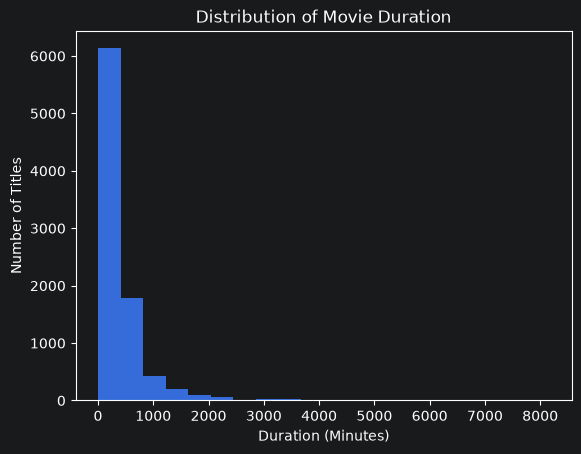

In [14]:
plt.hist(data['duration'].dropna(), bins=20)

plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Titles")
plt.title("Distribution of Movie Duration")

plt.show()

### Observation

Most Netflix movies have durations between 80 and 120 minutes.

# 15. Bar Graph – Top Ratings

The graph displays the most common content ratings.

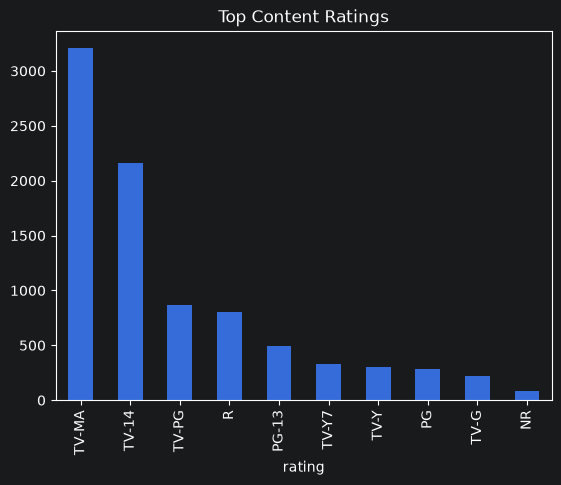

In [15]:
data['rating'].value_counts().head(10).plot(kind='bar')

plt.title("Top Content Ratings")

plt.show()

### Observation

TV-MA and TV-14 are among the most common ratings, indicating a large amount of mature content.

# 16. Histogram – Release Year Distribution

This histogram shows the release years of Netflix titles.

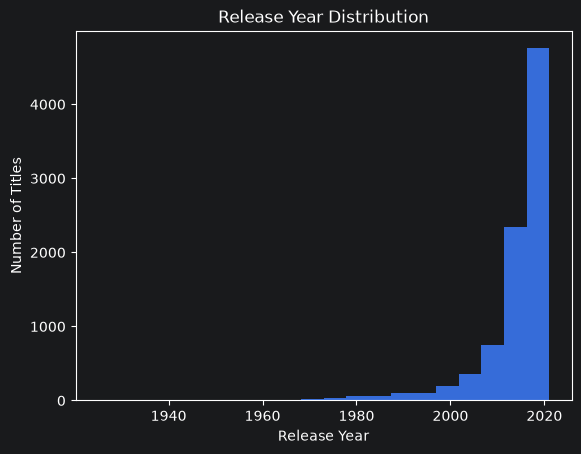

In [16]:
plt.hist(data['release_year'], bins=20)

plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.title("Release Year Distribution")

plt.show()

### Observation

Most titles available on Netflix are relatively recent releases.

# 17. Pie Chart – Movies vs TV Shows

The pie chart represents the percentage of movies and TV shows available on Netflix.

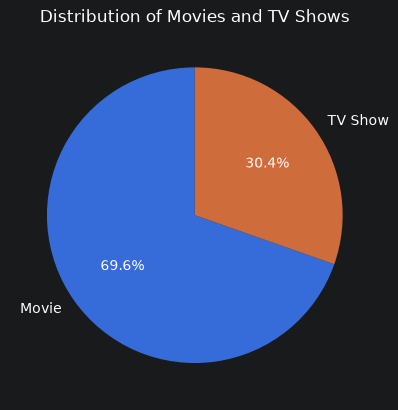

In [17]:
plt.pie(
    data['type'].value_counts(),
    labels=data['type'].value_counts().index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Distribution of Movies and TV Shows")

plt.show()

### Observation

Movies make up the majority of Netflix's content library.

# 18. Scatter Plot – Release Year vs Encoded Rating

Ratings are converted into numeric values to visualize their relationship with release years.

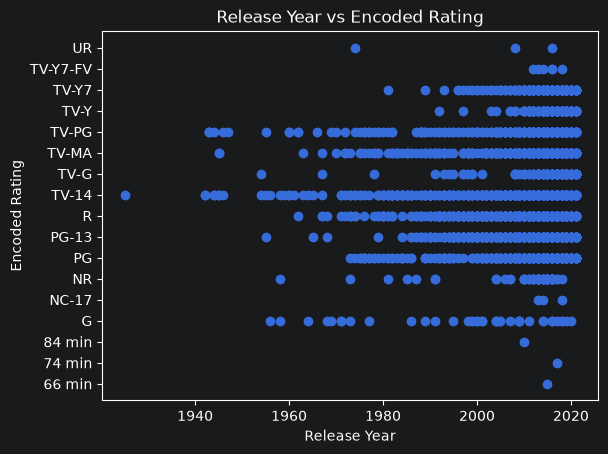

In [18]:
rating_map = {
    rating:index
    for index,rating in enumerate(sorted(data['rating'].dropna().unique()))
}

data['encoded_Rating'] = data['rating'].map(rating_map)

plt.scatter(data['release_year'], data['encoded_Rating'])

plt.title("Release Year vs Encoded Rating")
plt.xlabel("Release Year")
plt.ylabel("Encoded Rating")

plt.yticks(
    list(rating_map.values()),
    list(rating_map.keys())
)

plt.show()

### Observation

Content with different audience ratings is distributed across almost every release year, with no strong relationship between release year and content rating.

# 19. Overall Findings

From the exploratory analysis, the following observations were made:

- Netflix contains more movies than TV shows.
- Content additions increased significantly after 2015.
- Most movies have durations between 80 and 120 minutes.
- Mature-rated content (TV-MA and TV-14) is the most common.
- Most Netflix titles were released in recent years.

# 20. Conclusion

This project demonstrated how Exploratory Data Analysis (EDA) can be used to understand large datasets through data cleaning, statistical analysis, and visualization. Using Pandas and Matplotlib, meaningful insights were obtained regarding Netflix's content distribution, release trends, duration patterns, and content ratings. These insights help better understand the characteristics of the Netflix content library and demonstrate the importance of visualization in data analysis.